# 05 — Visualization: Answering the Business Questions

No Spark needed here — the Gold tables are already small, aggregated business metrics. Just pandas + Matplotlib + Seaborn, reading directly from `data/gold/`.

Charts are saved to `reports/figures/` as PNG so they can be embedded directly in the README.

In [1]:
import os
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath(os.path.join("..", "src")))
from battle_engine import ALL_TYPES

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 100

GOLD_PATH = "../data/gold"
FIGURES_PATH = "../reports/figures"
os.makedirs(FIGURES_PATH, exist_ok=True)


def savefig(name):
    plt.savefig(f"{FIGURES_PATH}/{name}.png", dpi=150, bbox_inches="tight")


print("Ready.")

Ready.


## 1 — Which type has the highest real win rate?

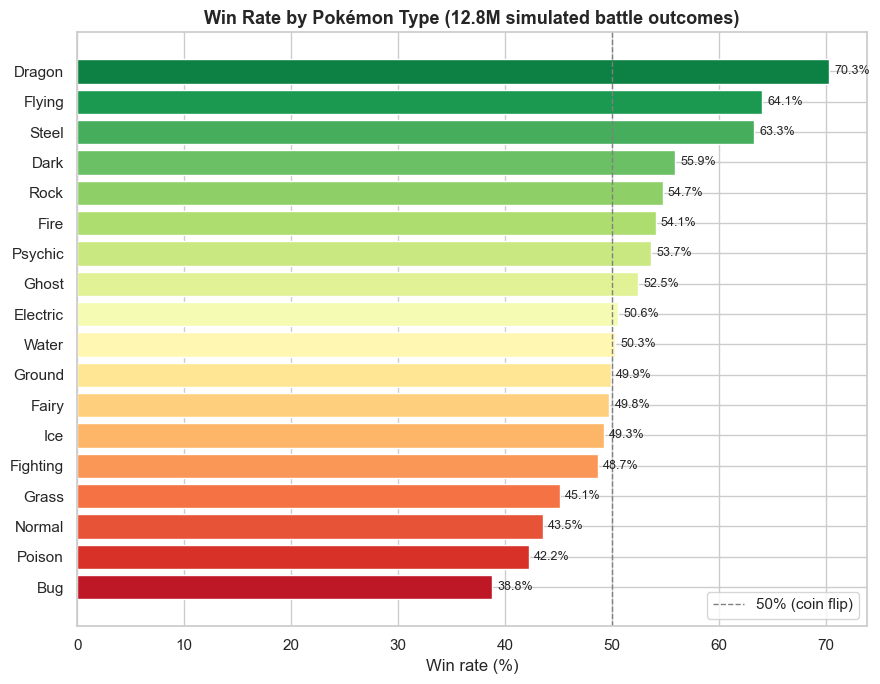

In [2]:
df = pd.read_parquet(f"{GOLD_PATH}/win_rate_by_type").sort_values("win_rate_pct", ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors = sns.color_palette("RdYlGn", n_colors=len(df))
bars = ax.barh(df["type_1"], df["win_rate_pct"], color=colors)
ax.axvline(50, color="gray", linestyle="--", linewidth=1, label="50% (coin flip)")
ax.set_xlabel("Win rate (%)")
ax.set_ylabel("")
ax.set_title("Win Rate by Pokémon Type (12.8M simulated battle outcomes)", fontsize=13, fontweight="bold")
ax.legend()

for bar, value in zip(bars, df["win_rate_pct"]):
    ax.text(value + 0.5, bar.get_y() + bar.get_height() / 2, f"{value:.1f}%", va="center", fontsize=9)

plt.tight_layout()
savefig("win_rate_by_type")
plt.show()

## 2 — Does Speed matter more than type advantage?

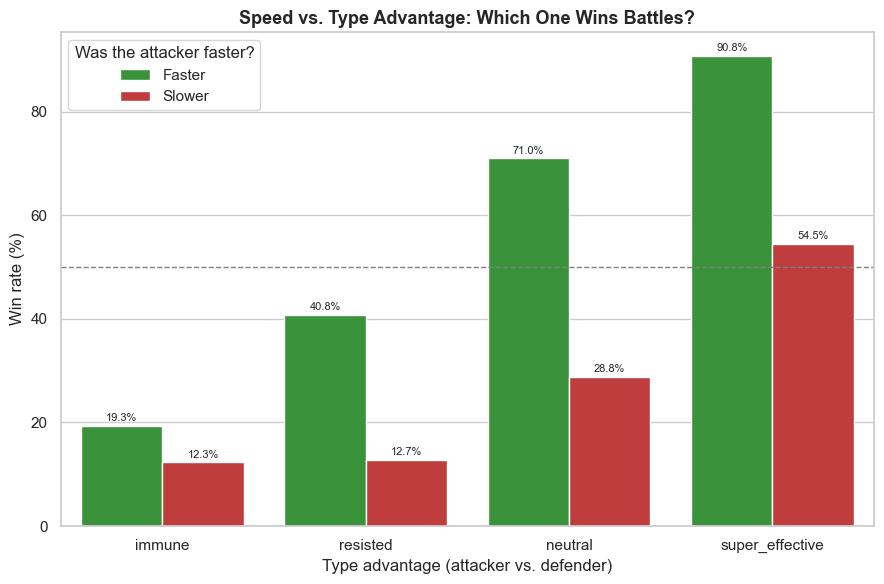

In [3]:
df = pd.read_parquet(f"{GOLD_PATH}/speed_vs_type_advantage")
order = ["immune", "resisted", "neutral", "super_effective"]
df["a_type_advantage"] = pd.Categorical(df["a_type_advantage"], categories=order, ordered=True)
df = df.sort_values("a_type_advantage")
df["speed_label"] = df["a_faster"].map({True: "Faster", False: "Slower"})

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(
    data=df, x="a_type_advantage", y="a_win_rate_pct", hue="speed_label",
    palette={"Faster": "#2ca02c", "Slower": "#d62728"}, ax=ax,
)
ax.axhline(50, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Type advantage (attacker vs. defender)")
ax.set_ylabel("Win rate (%)")
ax.set_title("Speed vs. Type Advantage: Which One Wins Battles?", fontsize=13, fontweight="bold")
ax.legend(title="Was the attacker faster?")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=8, padding=2)

plt.tight_layout()
savefig("speed_vs_type_advantage")
plt.show()

## 3 — Do legendary Pokémon really win more?

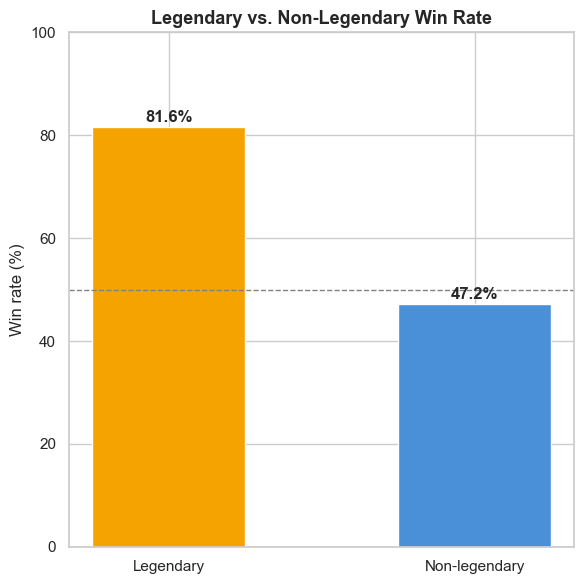

In [4]:
df = pd.read_parquet(f"{GOLD_PATH}/win_rate_by_legendary")
df["label"] = df["legendary"].map({True: "Legendary", False: "Non-legendary"})

fig, ax = plt.subplots(figsize=(6, 6))
bars = ax.bar(df["label"], df["win_rate_pct"], color=["#f4a300", "#4a90d9"], width=0.5)
ax.axhline(50, color="gray", linestyle="--", linewidth=1)
ax.set_ylabel("Win rate (%)")
ax.set_ylim(0, 100)
ax.set_title("Legendary vs. Non-Legendary Win Rate", fontsize=13, fontweight="bold")

for bar, value in zip(bars, df["win_rate_pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 1, f"{value:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
savefig("win_rate_by_legendary")
plt.show()

## 4 — Is there power creep across generations?

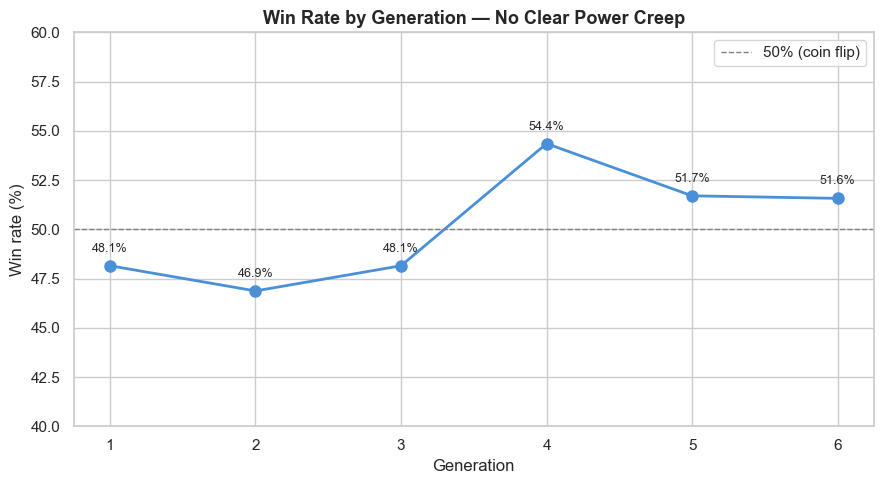

In [5]:
df = pd.read_parquet(f"{GOLD_PATH}/win_rate_by_generation").sort_values("generation")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df["generation"], df["win_rate_pct"], marker="o", markersize=8, linewidth=2, color="#4a90d9")
ax.axhline(50, color="gray", linestyle="--", linewidth=1, label="50% (coin flip)")
ax.set_xlabel("Generation")
ax.set_ylabel("Win rate (%)")
ax.set_xticks(df["generation"])
ax.set_ylim(40, 60)
ax.set_title("Win Rate by Generation — No Clear Power Creep", fontsize=13, fontweight="bold")
ax.legend()

for x, y in zip(df["generation"], df["win_rate_pct"]):
    ax.annotate(f"{y:.1f}%", (x, y), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9)

plt.tight_layout()
savefig("win_rate_by_generation")
plt.show()

## 5 — Simulated type matchup matrix vs. the official chart

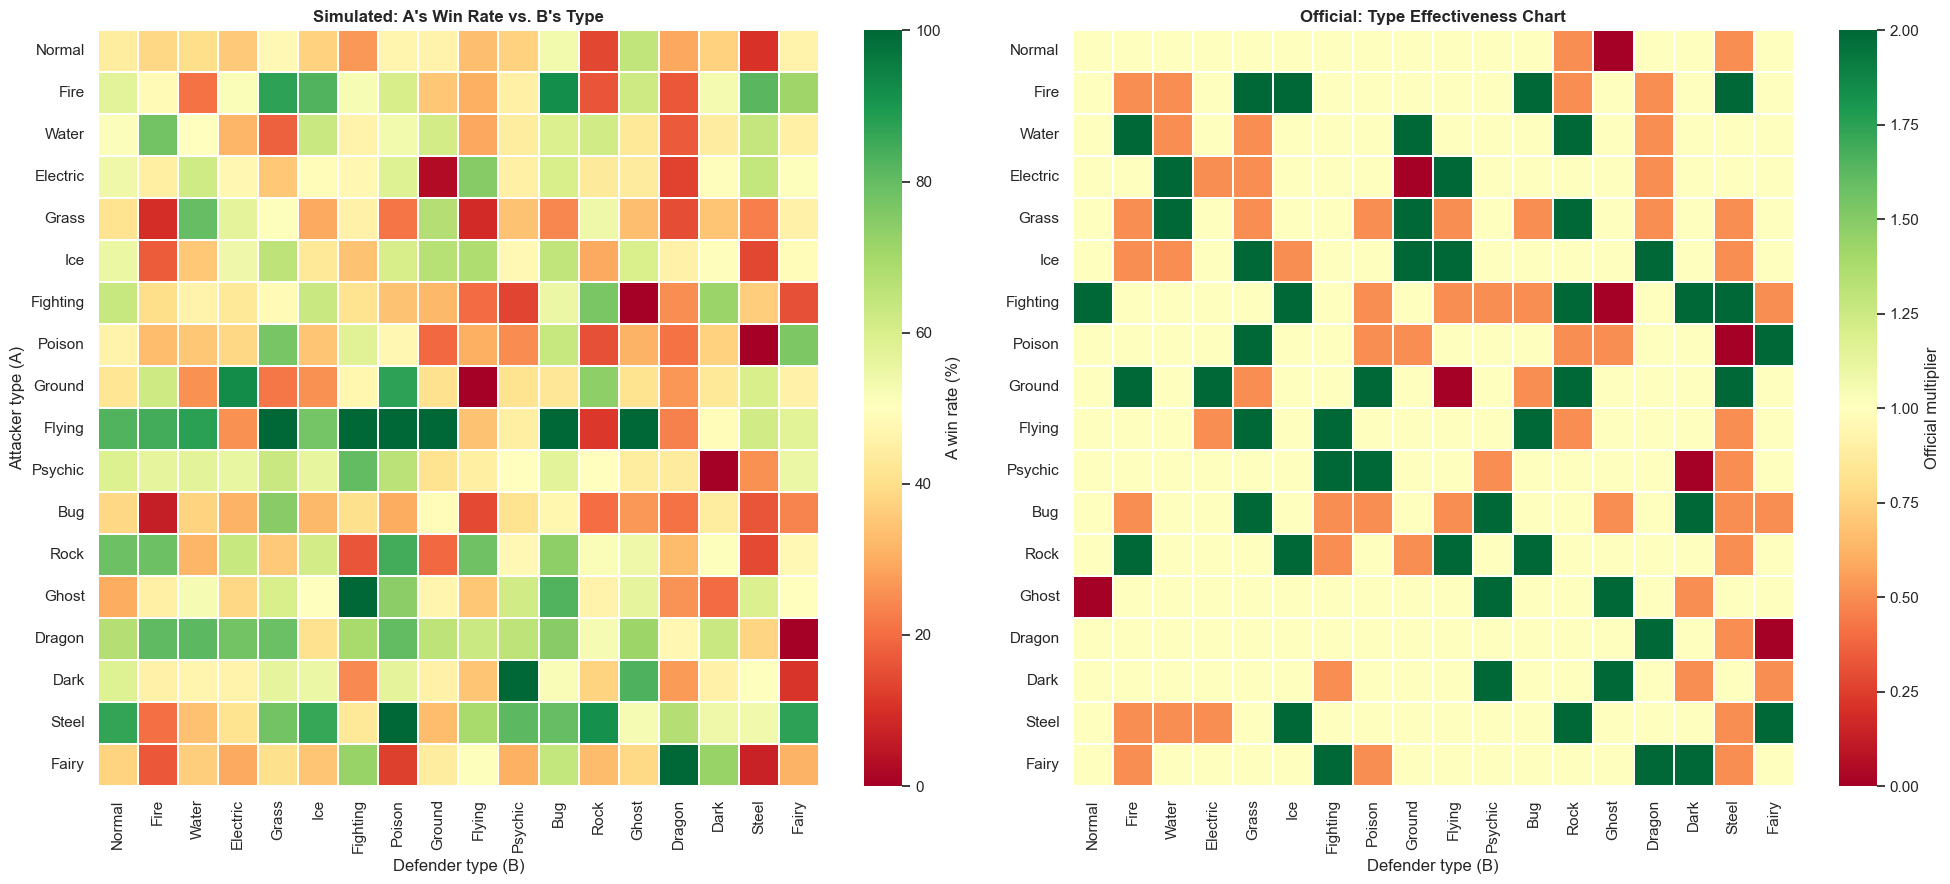

Correlation between simulated win rate and official multiplier: 0.651


In [6]:
df = pd.read_parquet(f"{GOLD_PATH}/type_matchup_matrix")

pivot_simulated = df.pivot(index="type_1_a", columns="type_1_b", values="a_win_rate_pct").reindex(
    index=ALL_TYPES, columns=ALL_TYPES
)
pivot_official = df.pivot(index="type_1_a", columns="type_1_b", values="official_multiplier").reindex(
    index=ALL_TYPES, columns=ALL_TYPES
)

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

sns.heatmap(
    pivot_simulated, cmap="RdYlGn", center=50, ax=axes[0],
    cbar_kws={"label": "A win rate (%)"}, linewidths=0.3, linecolor="white",
)
axes[0].set_title("Simulated: A's Win Rate vs. B's Type", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Defender type (B)")
axes[0].set_ylabel("Attacker type (A)")

sns.heatmap(
    pivot_official, cmap="RdYlGn", center=1.0, ax=axes[1],
    cbar_kws={"label": "Official multiplier"}, linewidths=0.3, linecolor="white",
)
axes[1].set_title("Official: Type Effectiveness Chart", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Defender type (B)")
axes[1].set_ylabel("")

plt.tight_layout()
savefig("type_matchup_matrix")
plt.show()

correlation = df["a_win_rate_pct"].corr(df["official_multiplier"])
print(f"Correlation between simulated win rate and official multiplier: {correlation:.3f}")

## 6 — Original dataset vs. large-scale simulation

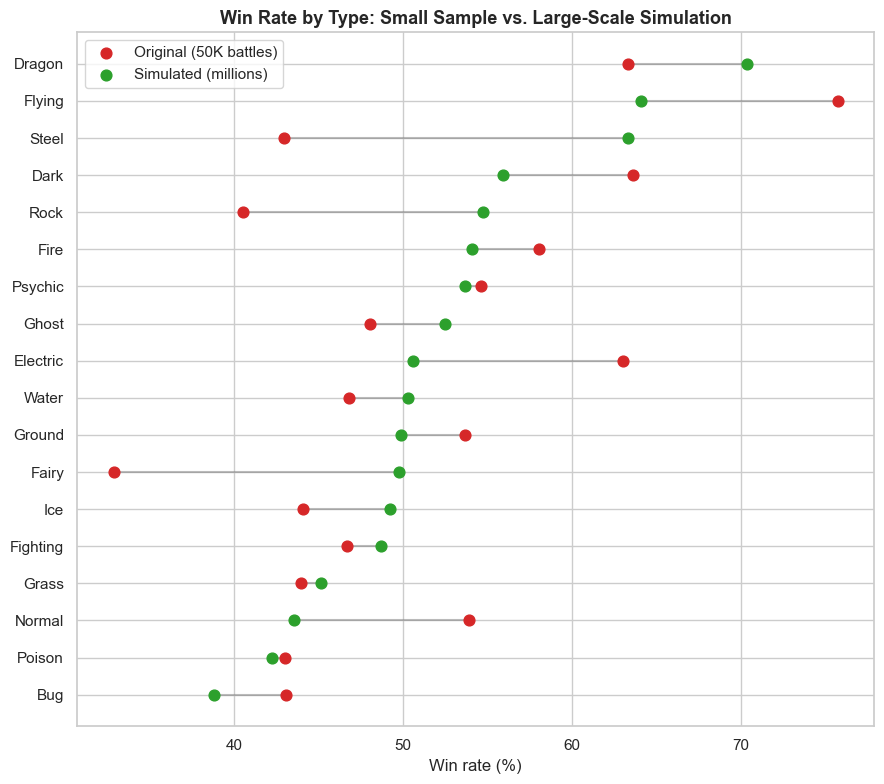

In [7]:
df = pd.read_parquet(f"{GOLD_PATH}/win_rate_comparison_original_vs_simulated").sort_values(
    "win_rate_pct_simulated", ascending=True
)

fig, ax = plt.subplots(figsize=(9, 8))
y_pos = range(len(df))

ax.hlines(y=y_pos, xmin=df["win_rate_pct_original"], xmax=df["win_rate_pct_simulated"], color="gray", alpha=0.5)
ax.scatter(df["win_rate_pct_original"], y_pos, color="#d62728", label="Original (50K battles)", zorder=3, s=60)
ax.scatter(df["win_rate_pct_simulated"], y_pos, color="#2ca02c", label="Simulated (millions)", zorder=3, s=60)

ax.set_yticks(y_pos)
ax.set_yticklabels(df["type_1"])
ax.set_xlabel("Win rate (%)")
ax.set_title("Win Rate by Type: Small Sample vs. Large-Scale Simulation", fontsize=13, fontweight="bold")
ax.legend()

plt.tight_layout()
savefig("win_rate_comparison_original_vs_simulated")
plt.show()

## Done

All 6 charts saved to `reports/figures/` — ready to embed directly in the README with:
```markdown
![Win rate by type](reports/figures/win_rate_by_type.png)
```